<a href="https://colab.research.google.com/github/reneenarushoff/cmu-volleyball-ml/blob/main/CMU_Vball_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Applying Linear and Logistic regression to CMU Volleyball

*Using [2025-2026 CMU Gamelog data ](https://athletics.cmu.edu/sports/wvball/2025-26/teams/carnegiemellon?view=gamelog)*

The goal of this project is to predict whether passing and defense affect how efficiently CMU hits using linear regression.

Based on Machine Learning Introduction adapted from https://carpentries-incubator.github.io/machine-learning-novice-sklearn/index.html

In [23]:
import pandas as pd
import numpy as np

df = pd.read_csv("https://raw.githubusercontent.com/reneenarushoff/cmu-volleyball-ml/refs/heads/main/CMU%202025-26%20Volleyball%20Game%20Log%20-%20Sheet1.csv")
df.head()

,Date,Opponent,Score,s,k,e,ta,pct,a,sa,se,r,re,digs,bs,ba,be,tot,bhe,pts
0,Aug 29,at Gettysburg,"W, 3-1",4,55,27,168,0.167,46,12,11,84,9,63,3,14,4,10,0,77
1,Aug 30,vs. Messiah,"W, 3-1",4,47,23,137,0.175,44,8,11,74,7,73,0,24,1,12,0,67
2,Aug 30,vs. Otterbein,"L, 3-2",5,39,20,148,0.128,38,10,13,86,8,67,3,14,3,10,0,59
3,Sep 3,St. Vincent,"W, 3-0",3,40,10,81,0.37,35,17,5,28,1,37,4,4,0,6,0,63
4,Sep 5,vs. Mt. St. Joseph,"W, 3-0",3,41,13,100,0.28,36,10,7,46,4,57,1,12,0,7,0,58


Hitting % formaula = (kills − attack errors) ÷ total attacks. In this linear regression, I am exploring whether passing and defense have any impact before the attack, affecting hitting %.

Target (y) = Hitting percentage (pct)
Features (X), all per set:

1. Reception errors (re)
2. Receptions (r)
3. Digs



In [24]:
cols = ["s","r","re","digs","pct"]
df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")
df.dropna(subset=cols, inplace=True)

#Per set rates to compare matches
df["re_per_set"] = df["re"]/df["s"]
df["r_per_set"] = df["r"]/df["s"]
df["digs_per_set"]= df["digs"]/df["s"]

In [25]:
features = ["re_per_set","r_per_set","digs_per_set"]
X=df[features]
Y = df["pct"]

<function matplotlib.pyplot.show(close=None, block=None)>

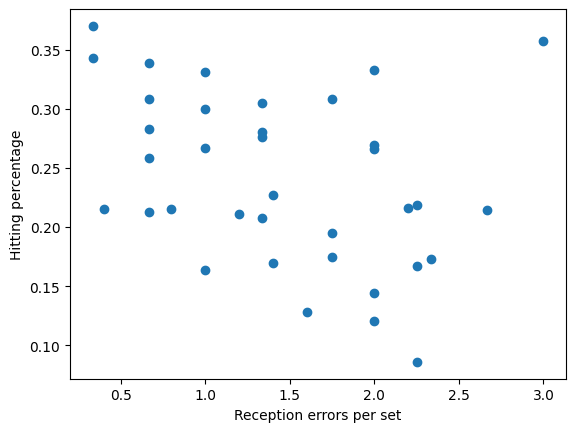

In [26]:
#Test viz with one x variable
import matplotlib.pyplot as plt

plt.scatter(df["re_per_set"], df["pct"])
plt.xlabel("Reception errors per set")
plt.ylabel("Hitting percentage")
plt.show


pct
(0.08499999999999999, 0.212]    12
(0.212, 0.277]                  12
(0.277, 0.37]                   12
Name: count, dtype: int64


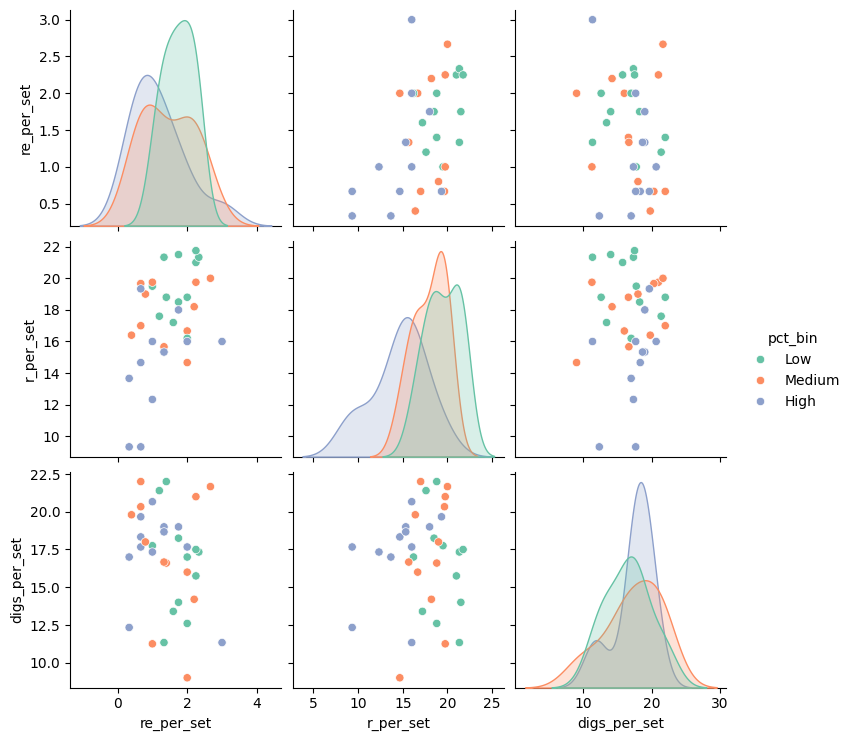

In [27]:
#Use pairplot to vizualize all features
import seaborn as sns

#Bin pct groups
df["pct_bin"] = pd.qcut(df["pct"], q=3, labels=["Low","Medium","High"])
print(pd.qcut(df["pct"], q=3).value_counts().sort_index())

sns.pairplot(
    df,
    vars=df[features],
    hue="pct_bin",
    palette="Set2",
    corner=False
)

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=0
)

In [29]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [30]:
print(f"Intercept (Base pct): {model.intercept_:4f}")
for feature_name, coef in zip(X.columns, model.coef_):
  print(f"Weight for {feature_name}: {coef:.4f}")

Intercept (Base pct): 0.467182
Weight for re_per_set: -0.0112
Weight for r_per_set: -0.0112
Weight for digs_per_set: -0.0004


* Intercept (Base pct): 0.467182
* Weight for re_per_set: -0.0112
* Weight for r_per_set: -0.0112
* Weight for digs_per_set: -0.0004

Reception errors contributed -0.011 per error per set, meaning matches where CMU's passing was worse also saw lower hitting efficiency. Most likely, bad passes limit setting options.

Receptions contributed -0.011 per reception per set, most likely pointing to the strength of the opposing team, given that receptions happen after the other team gains a point.

Digs (-0.0004) had negligible results in relation to reception errors and receptions.






In [31]:
Y_pred = model.predict(X_test)

In [32]:
from sklearn.metrics import mean_squared_error, r2_score

rmse=np.sqrt(mean_squared_error(Y_test, Y_pred))
r2=r2_score(Y_test, Y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")


Root Mean Squared Error (RMSE): 0.0676
R2 Score: 0.1543


RMSE: 0.68
R2: 0.15

Prediction is off by .068 on average. Given that CMU's hitting percentage ranges from .086 to .370 this is a sizeable error margin. R2=.15, meaning receptions, reception errors and digs are responsible for about 15% of hitting percentage variation in each match.

Because this R2 comes from an 80/20 split in the data earlier, it is based on only appoximately 7 matches. This amount is low, so running cross-validation will confirm whether the average R2 across folds is consistent.

In [33]:
#Running cross-validation to account for small dataset
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = cross_val_score(LinearRegression(), X, Y, cv=kf, scoring="r2")

print("R2 for each fold:", np.round(cv_scores, 2))
print(f"Average R2: {cv_scores.mean():.2f} (± {cv_scores.std():.2f})")

R2 for each fold: [ 0.15 -0.12 -0.29  0.01  0.02]
Average R2: -0.04 (± 0.15)


R2 for each fold: [ 0.15 -0.12 -0.29  0.01  0.02]
Average R2: -0.04 (± 0.15)

Across all 36 matches, the R2 score averaged -0.04, which is more unreliable than the previously calculated single-split R2 of 0.15.

This model does no better than predicting the season average, and the 0.15 came from a favorable split. With one season of data, these features alone can't explain match-to-match variation in hitting percentage. Some coefficient directions are worth exploring with more data (receptions and reception errors), but we are not left with a reliable conclusion here.

Further exploration: Using logistic regression for win-loss analysis and continuing this analysis with more data.